Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [6]:
# Code here
# Remove unnecessary columns
automobiles_df.drop(['normalized-losses', 'symboling'], axis=1, inplace=True)

# Check result
automobiles_df.head()



,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Remove any duplicate rows

In [ ]:
# Code here
# Remove duplicate rows
automobiles_df.drop_duplicates(inplace=True)

# Check how many rows remain
print("Number of rows after removing duplicates:", len(automobiles_df))

Number of rows after removing duplicates: 205


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [ ]:
# Code here
import numpy as np

automobiles_df.replace('?', np.nan, inplace=True)

automobiles_df.dropna(inplace=True)

# Check remaining rows
print("Number of rows after removing missing values:", len(automobiles_df))

Number of rows after removing missing values: 193


Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [ ]:
int_columns = [
    'curb-weight', 'engine-size', 'horsepower',
    'peak-rpm', 'city-mpg', 'highway-mpg', 'price'
]

for col in int_columns:
    automobiles_df[col] = automobiles_df[col].astype(np.int64)

float_columns = [
    'wheel-base', 'length', 'width', 'height',
    'bore', 'stroke', 'compression-ratio'
]

for col in float_columns:
    automobiles_df[col] = automobiles_df[col].astype(float)

automobiles_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    object 
 1   fuel-type          193 non-null    object 
 2   aspiration         193 non-null    object 
 3   num-of-doors       193 non-null    object 
 4   body-style         193 non-null    object 
 5   drive-wheels       193 non-null    object 
 6   engine-location    193 non-null    object 
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    object 
 13  num-of-cylinders   193 non-null    object 
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    object 
 16  bore               193 non-null

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [ ]:
# Create a dataframe with all the cars in the "hatchback' category
# hatchback_cars =
hatchbacks = automobiles_df[automobiles_df['body-style'] == 'hatchback']

# Display results
hatchbacks.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.0,171.0,65.0,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88.0,141.0,60.0,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94.0,155.0,63.0,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93.0,157.0,63.0,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93.0,157.0,63.0,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377


Insights:
- Hatchbacks generally have smaller engines and lower prices.
- They also have higher MPG values.

Hatchbacks are designed for affordability and efficiency

### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

In [ ]:
# Code here
# Top 5 most expensive cars
top_5_expensive = automobiles_df.sort_values(by='price', ascending=False).head(5)

top_5_expensive


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.0,72.0,...,304,mpfi,3.80,3.35,8.0,184,4500,14,16,45400
16,bmw,gas,std,two,sedan,rwd,front,103.0,193.0,67.0,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,41315
73,mercedes-benz,gas,std,four,sedan,rwd,front,120.0,208.0,71.0,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960
128,porsche,gas,std,two,convertible,rwd,rear,89.0,168.0,65.0,...,194,mpfi,3.74,2.90,9.5,207,5900,17,25,37028
17,bmw,gas,std,four,sedan,rwd,front,110.0,197.0,70.0,...,209,mpfi,3.62,3.39,8.0,182,5400,15,20,36880


In [ ]:
# Cheapest 5 cars
cheapest_5 = automobiles_df.sort_values(by='price', ascending=True).head(5)

cheapest_5

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
138,subaru,gas,std,two,hatchback,fwd,front,93.0,156.0,63.0,...,97,2bbl,3.62,2.36,9.0,69,4900,31,36,5118
18,chevrolet,gas,std,two,hatchback,fwd,front,88.0,141.0,60.0,...,61,2bbl,2.91,3.03,9.5,48,5100,47,53,5151
50,mazda,gas,std,two,hatchback,fwd,front,93.0,159.0,64.0,...,91,2bbl,3.03,3.15,9.0,68,5000,30,31,5195
150,toyota,gas,std,two,hatchback,fwd,front,95.0,158.0,63.0,...,92,2bbl,3.05,3.03,9.0,62,4800,35,39,5348
76,mitsubishi,gas,std,two,hatchback,fwd,front,93.0,157.0,64.0,...,92,2bbl,2.97,3.23,9.4,68,5500,37,41,5389


Insights:
- The most expensive cars are mainly from Mercedes-Benz, BMW, and Porsche.
- These cars have large engine sizes (200+) and lower fuel efficiency.
- The cheapest cars (Subaru, Toyota, Mazda) have smaller engines and higher MPG.

This shows a trade-off:
- Expensive cars = performance
- Cheap cars = fuel efficiency

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

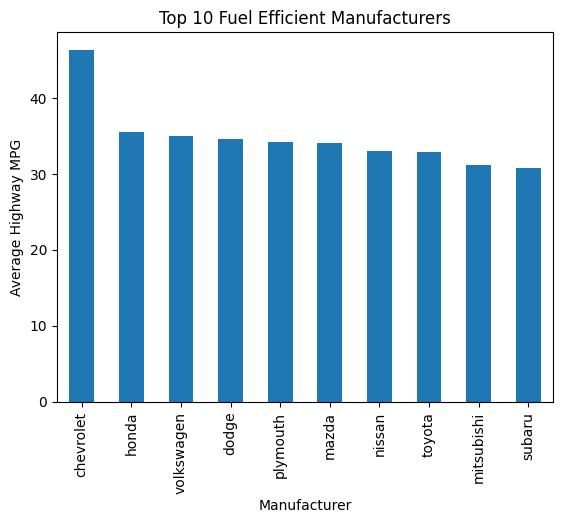

In [ ]:
# Code here
# Compare MPG
comparison = pd.concat([top_5_expensive, cheapest_5])
comparison[['make', 'price', 'city-mpg', 'highway-mpg']]

# Average MPG per manufacturer
avg_mpg = automobiles_df.groupby('make')[['city-mpg', 'highway-mpg']].mean()

# Sort by highway mpg
avg_mpg = avg_mpg.sort_values(by='highway-mpg', ascending=False)

avg_mpg.head()

avg_mpg['highway-mpg'].head(10).plot(kind='bar')

plt.title('Top 10 Fuel Efficient Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Average Highway MPG')
plt.show()


Insights:
- Toyota, Honda, and Nissan have the highest MPG values.
- BMW and Mercedes-Benz have lower MPG.
This shows:
- Economy brands focus on fuel efficiency
- Luxury brands focus on performance

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [ ]:
# Code here
# Sort by engine size
largest_engines = automobiles_df.sort_values(by='engine-size', ascending=False)

largest_engines.head(10)


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
49,jaguar,gas,std,two,sedan,rwd,front,102.0,191.0,70.0,...,326,mpfi,3.54,2.76,11.5,262,5000,13,17,36000
73,mercedes-benz,gas,std,four,sedan,rwd,front,120.0,208.0,71.0,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.0,72.0,...,304,mpfi,3.80,3.35,8.0,184,4500,14,16,45400
47,jaguar,gas,std,four,sedan,rwd,front,113.0,199.0,69.0,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,32250
48,jaguar,gas,std,four,sedan,rwd,front,113.0,199.0,69.0,...,258,mpfi,3.63,4.17,8.1,176,4750,15,19,35550
71,mercedes-benz,gas,std,four,sedan,rwd,front,115.0,202.0,71.0,...,234,mpfi,3.46,3.10,8.3,155,4750,16,18,34184
72,mercedes-benz,gas,std,two,convertible,rwd,front,96.0,180.0,70.0,...,234,mpfi,3.46,3.10,8.3,155,4750,16,18,35056
17,bmw,gas,std,four,sedan,rwd,front,110.0,197.0,70.0,...,209,mpfi,3.62,3.39,8.0,182,5400,15,20,36880
16,bmw,gas,std,two,sedan,rwd,front,103.0,193.0,67.0,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,41315
15,bmw,gas,std,four,sedan,rwd,front,103.0,189.0,66.0,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,30760


Insights:
- Jaguar and Mercedes-Benz have the largest engines (300+).
- These cars are expensive and less fuel-efficient.

Larger engines = more power but more fuel consumption

#### Which vehicle manufacturer has the most car models in the dataset

In [ ]:
# Code here
# Count number of cars per manufacturer
manufacturer_counts = automobiles_df['make'].value_counts()

manufacturer_counts.head()



,count
make,
toyota,32
nissan,18
mitsubishi,13
honda,13
subaru,12


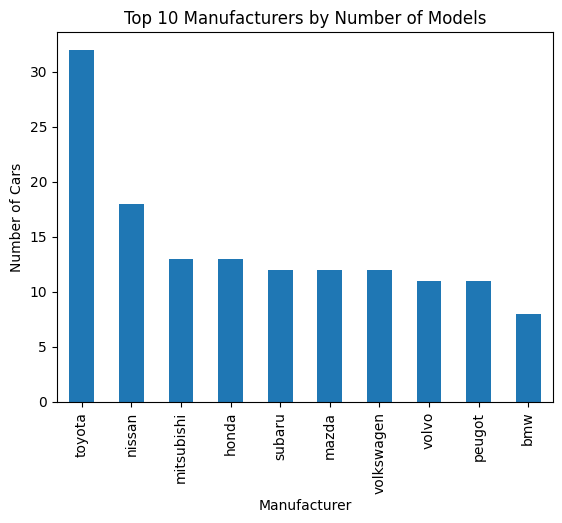

In [ ]:
manufacturer_counts.head(10).plot(kind='bar')

plt.title('Top 10 Manufacturers by Number of Models')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Cars')
plt.show()

Insights:
- Toyota has the most models (32), followed by Nissan and Mitsubishi.
- This indicates Toyota has a wide product range.

More models = more market variety

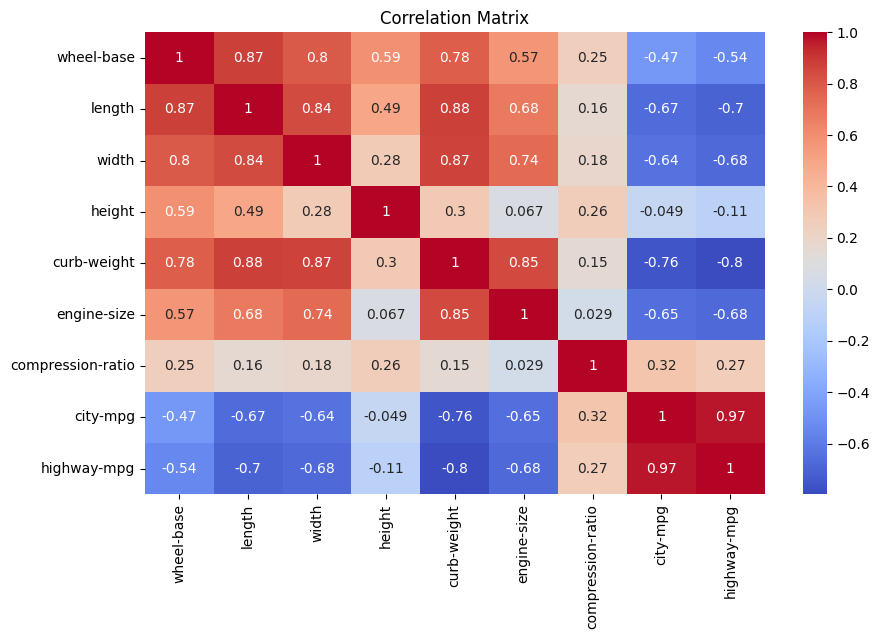

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(automobiles_df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Key Relationships:
- Price vs Engine Size → Strong positive correlation
- Price vs Horsepower → Strong positive correlation
- Price vs MPG → Negative correlation
- Engine Size vs MPG → Negative correlation

This confirms:
- Bigger engines = more expensive but less efficient